# 03 – Forecasting Models
Ziel: Alle 4 Modelle trainieren und Forecast-Metriken vergleichen.

In [1]:
import importlib
import pandas as pd
import numpy as np
import sys
sys.path.append('..')

import src.utils.metrics as metrics_module
import src.forecasting.train as train_module
import src.forecasting.evaluate_forecast as evaluate_module
import src.utils.plotting as plotting_module
from src.models import (linear_regression, random_forest, neural_net,
                        quantile_regression, persistence_model,
                        quantile_regression_forest, arima, decomposition)

importlib.reload(metrics_module)
importlib.reload(train_module)
importlib.reload(evaluate_module)
importlib.reload(plotting_module)

prepare_data = train_module.prepare_data
scale_features = train_module.scale_features
evaluate_all = evaluate_module.evaluate_all
plot_forecast_vs_actual = plotting_module.plot_forecast_vs_actual
plot_metric_comparison = plotting_module.plot_metric_comparison
from src.utils.plotting import plot_quantile_forecast
print(f'Plots werden gespeichert unter: {plotting_module.SAVE_PATH}')

Plots werden gespeichert unter: C:\Users\felix\Documents\AI1\wind_bidding_project\results\figures


## Daten laden

In [2]:
df = pd.read_csv('../data/processed/final_dataset.csv', parse_dates=['timestamp'])
print(df.shape)
df.head()

(6600, 10)


,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos
0,2016-03-31 11:00:00,-11.000000,2.566667,11,3,3,2.588190e-01,-0.965926,0.433884,-0.900969
1,2016-03-31 12:00:00,-7.666667,3.616667,12,3,3,1.224647e-16,-1.000000,0.433884,-0.900969
2,2016-03-31 13:00:00,30.666667,3.533333,13,3,3,-2.588190e-01,-0.965926,0.433884,-0.900969
3,2016-03-31 14:00:00,169.833333,4.783333,14,3,3,-5.000000e-01,-0.866025,0.433884,-0.900969
4,2016-03-31 15:00:00,45.000000,0.800000,15,3,3,-7.071068e-01,-0.707107,0.433884,-0.900969


## Train/Test Split
`shuffle=False` ist bei Zeitreihen Pflicht – keine zufällige Aufteilung!

In [3]:
X_train, X_test, y_train, y_test = prepare_data(df)
X_sc_train, X_sc_test, scaler = scale_features(X_train, X_test)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Features: {X_train.shape[1]}')

Train: 5280, Test: 1320
Features: 5


## 0. Persistence Model

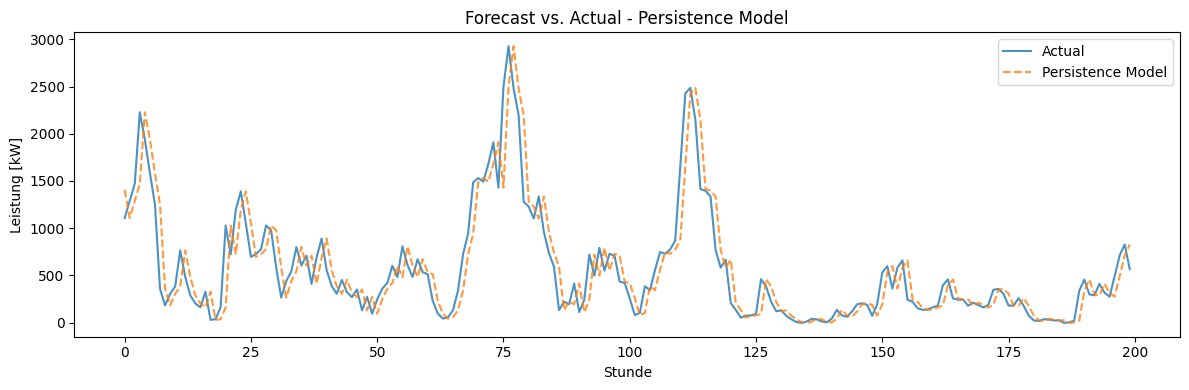

In [4]:
pm_model   = persistence_model.train(X_train, y_train)
import numpy as np
y_prev     = np.concatenate([[pm_model["last_obs"]], y_test[:-1]])
y_pred_pm  = persistence_model.predict(pm_model, X_test, y_prev)
plot_forecast_vs_actual(y_test, y_pred_pm, 'Persistence Model')

## 1. Linear Regression

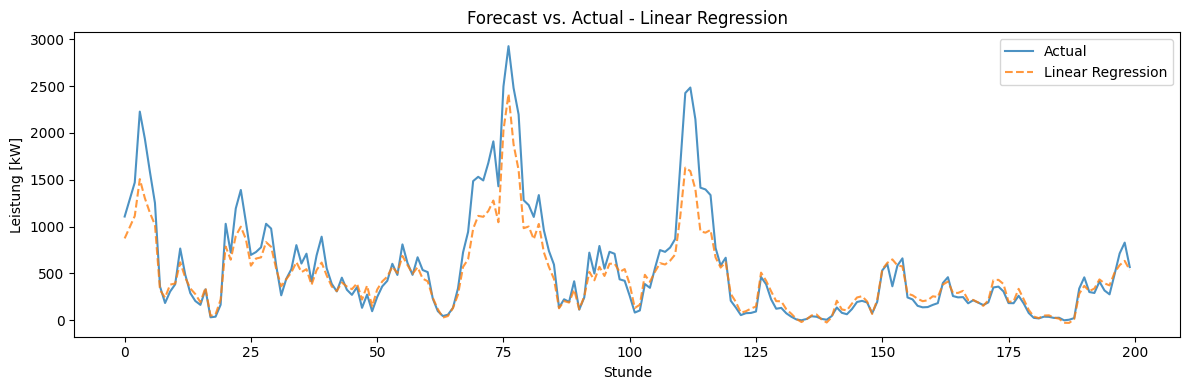

In [5]:
lr_model  = linear_regression.train(X_train, y_train, polynomial_degree=2)
y_pred_lr = linear_regression.predict(lr_model, X_test)
plot_forecast_vs_actual(y_test, y_pred_lr, 'Linear Regression')

## 2. Random Forest

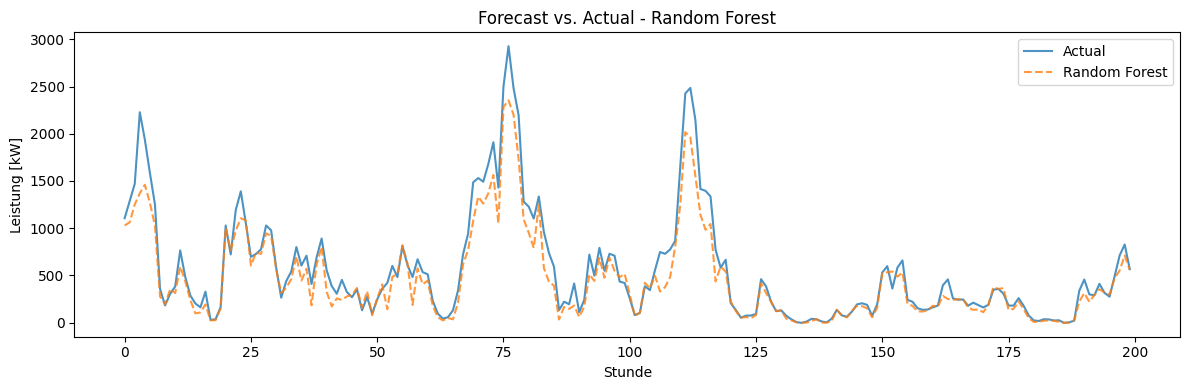

In [6]:
rf_model  = random_forest.train(X_train, y_train)
y_pred_rf = random_forest.predict(rf_model, X_test)
plot_forecast_vs_actual(y_test, y_pred_rf, 'Random Forest')

## 3. Neural Network

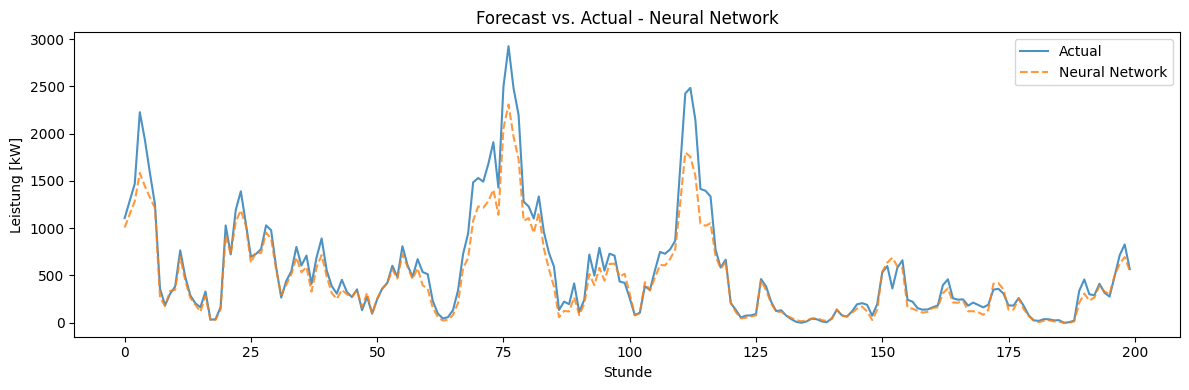

In [7]:
nn_model  = neural_net.train(X_sc_train, y_train, epochs=100)
y_pred_nn = neural_net.predict(nn_model, X_sc_test)
plot_forecast_vs_actual(y_test, y_pred_nn, 'Neural Network')

## 4. Quantile Regression

  Quantile 0.10 trainiert
  Quantile 0.25 trainiert
  Quantile 0.50 trainiert
  Quantile 0.75 trainiert
  Quantile 0.90 trainiert


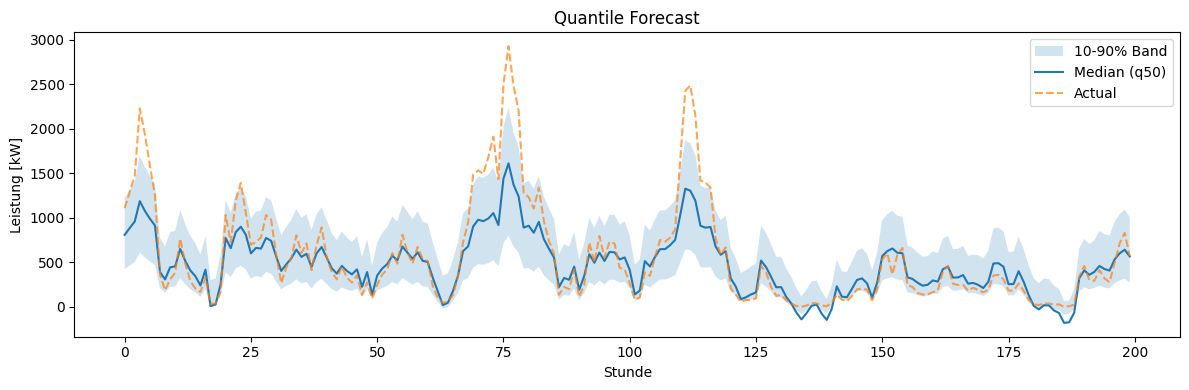

In [8]:
qr_models = quantile_regression.train_all_quantiles(X_train, y_train)
y_pred_q50 = quantile_regression.predict_quantile(qr_models, X_test, 0.5)

from src.utils.plotting import plot_quantile_forecast
q10 = quantile_regression.predict_quantile(qr_models, X_test, 0.1)
q90 = quantile_regression.predict_quantile(qr_models, X_test, 0.9)
plot_quantile_forecast(y_test, q10, y_pred_q50, q90)

## 5. Quantile Regression Forest

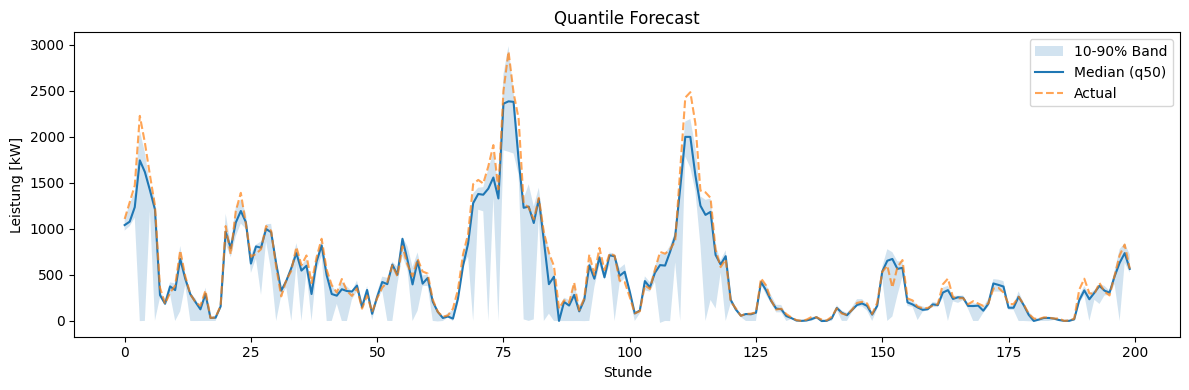

In [9]:
qrf_model  = quantile_regression_forest.train(X_train, y_train)
y_pred_qrf = quantile_regression_forest.predict(qrf_model, X_test, quantile=0.5)

qrf_q10 = quantile_regression_forest.predict(qrf_model, X_test, quantile=0.1)
qrf_q90 = quantile_regression_forest.predict(qrf_model, X_test, quantile=0.9)
plot_quantile_forecast(y_test, qrf_q10, y_pred_qrf, qrf_q90)

## 6. ARIMA

  auto_arima gewählt: order=(1, 1, 1)


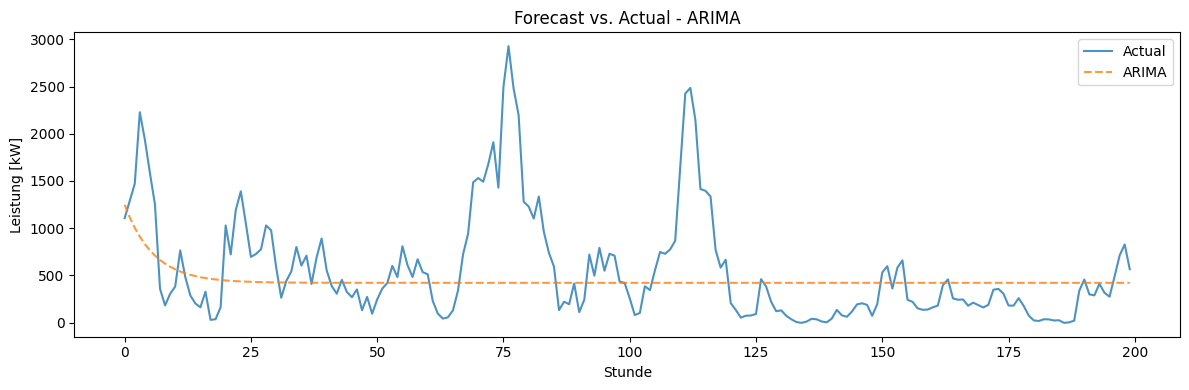

In [10]:
arima_model  = arima.train(y_train)
y_pred_arima = arima.predict(arima_model, steps=len(y_test))
plot_forecast_vs_actual(y_test, y_pred_arima, "ARIMA")

## 7. Zeitreihen-Dekomposition
Die Zeitreihe wird in **Trend**, **Saisonalität** und **Residuum** zerlegt.
Der Forecast kombiniert einen extrapolierten linearen Trend mit dem
wiederholten Saisonmuster (Periode = 24 h).

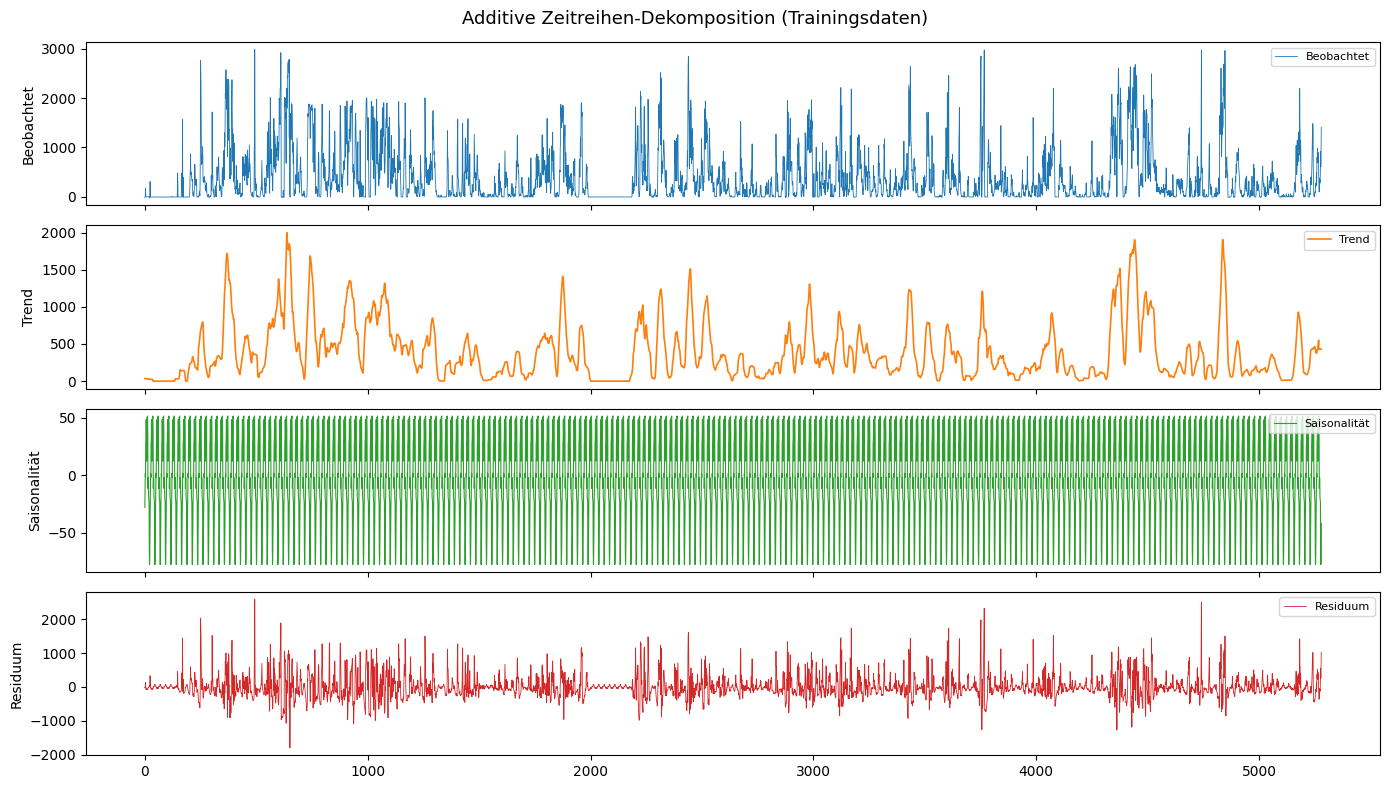

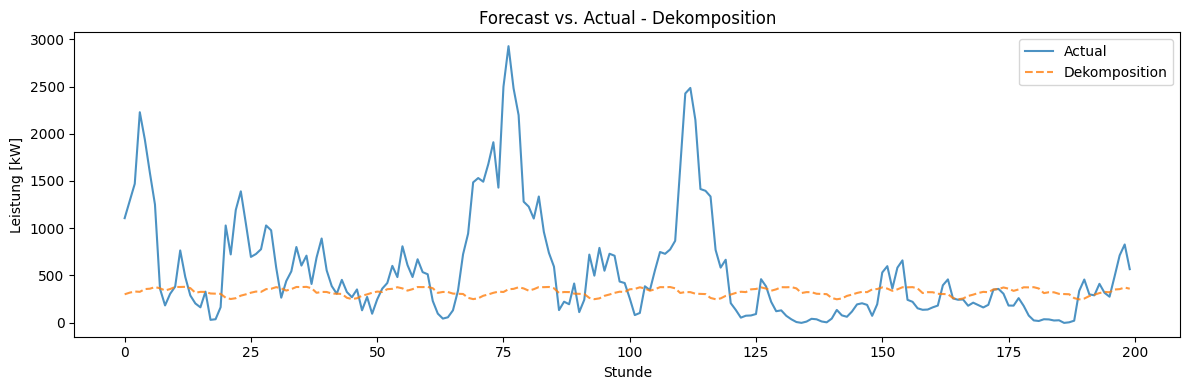

In [11]:
decomp_model   = decomposition.train(y_train)
y_pred_decomp  = decomposition.predict(decomp_model, steps=len(y_test))

# Dekompositions-Plot (Trend, Saisonalität, Residuum)
import matplotlib.pyplot as plt
dec = decomp_model["decomposition"]
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
axes[0].plot(dec.observed,   label="Beobachtet",  linewidth=0.6)
axes[0].set_ylabel("Beobachtet")
axes[1].plot(dec.trend,      label="Trend",       linewidth=1.2, color="tab:orange")
axes[1].set_ylabel("Trend")
axes[2].plot(dec.seasonal,   label="Saisonalität",linewidth=0.8, color="tab:green")
axes[2].set_ylabel("Saisonalität")
axes[3].plot(dec.resid,      label="Residuum",    linewidth=0.6, color="tab:red")
axes[3].set_ylabel("Residuum")
for ax in axes:
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("Additive Zeitreihen-Dekomposition (Trainingsdaten)", fontsize=13)
plt.tight_layout()
plt.savefig(plotting_module.SAVE_PATH / "decomposition_components.png", dpi=150, bbox_inches="tight")
plt.show()

plot_forecast_vs_actual(y_test, y_pred_decomp, "Dekomposition")

## Vergleich: Forecast-Metriken
**Wichtig**: Das ist NICHT die finale Bewertung – die kommt in Notebook 04.

In [12]:
models = {
    'Persistence':        pm_model,
    'LinearRegression':   lr_model,
    'RandomForest':       rf_model,
    'NeuralNet':          nn_model,
    'QuantileRegression': qr_models,
    'QRF':                qrf_model,
    'ARIMA':              arima_model,
    'Decomposition':      decomp_model,
}
df_results = evaluate_all(models, X_test, X_sc_test, y_test)
df_results


── Forecast Evaluation ──────────────────
                              rmse       mae      bias
Persistence               351.2393  181.2922    1.0702
LinearRegression          379.1676  195.5246  -54.5166
RandomForest              353.9605  176.4171  -77.7008
NeuralNet                 334.7918  161.8675  -57.1485
QuantileRegression (q50)  470.9001  291.5332 -165.2563
QRF (q50)                 349.3913  155.3834  -48.8576
ARIMA                     867.1026  585.5192 -194.3156
Decomposition             900.5840  565.3433 -306.9734


,rmse,mae,bias
Persistence,351.2393,181.2922,1.0702
LinearRegression,379.1676,195.5246,-54.5166
RandomForest,353.9605,176.4171,-77.7008
NeuralNet,334.7918,161.8675,-57.1485
QuantileRegression (q50),470.9001,291.5332,-165.2563
QRF (q50),349.3913,155.3834,-48.8576
ARIMA,867.1026,585.5192,-194.3156
Decomposition,900.5840,565.3433,-306.9734


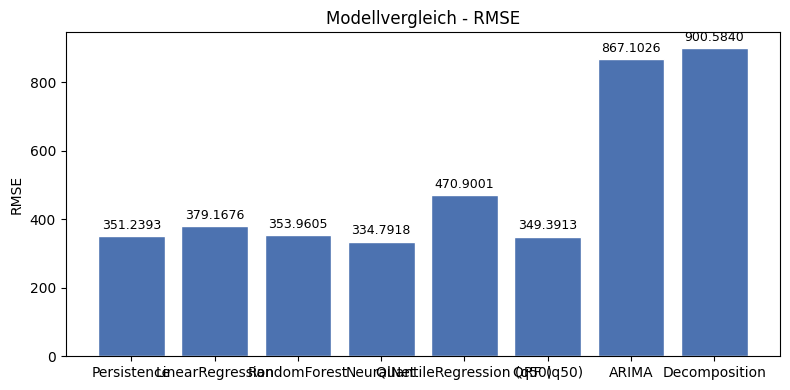

In [13]:
plot_metric_comparison(df_results.to_dict('index'), metric='rmse')

## Key Insight
Das RMSE-Ranking sagt noch nichts über den wirtschaftlichen Wert aus.
→ Weiter zu Notebook 04 für die echte Evaluation.